# Phase 2: single run (one expert regime)

Same bandit stack as `run_main_grid` (reward rescale + z-scored contexts, softmax router retrained on the active experts). Default is **one** regime so you get a single cumulative-regret figure like `02_single_run.ipynb`.

- Set `EXPERT_REGIME` to `"independent"` or `"joint"`.
- The **run + regret plot** live in **one code cell** so `pol` is only created after `run_main_grid` returns (running the plot alone will fail if the previous cell did not finish).
- To compare both regimes on disk, use `python main.py --regimes independent joint` or the optional cell at the bottom.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "moe_bandit").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'moe_bandit'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import logging

from moe_bandit.experiments import FixedSettings, run_main_grid

logging.basicConfig(level=logging.INFO, format="%(message)s")

Starting grid: output_dir=/Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run
Grid size: 1 cells (contaminations=1 × seps=1 × seeds=1), T=30000, n_train=10000
[1/1] contam_0.05_sep_2.0_seed_0 | contam=0.05 sep=2.0 | seeds train_data=101 train_experts=201 bandit=301 policy=401
Trained experts (independent) in 1.402s
Built R_raw (independent) in 0.009s shape=(30000, 5)
Trained softmax router (independent) in 29.677s (epochs=300, hidden=64, batch=64, lr=0.001)
Softmax in-sample metrics (independent): acc=0.7308 loss=0.711310
Policy uniform        (independent) done in 0.019s | final_cum_regret=14460.4819 avg_regret=0.482016 best_arm_acc=0.2018 mean_r=0.4632
Policy epsilon_greedy (independent) done in 0.043s | final_cum_regret=12985.7356 avg_regret=0.432858 best_arm_acc=0.2017 mean_r=0.5124
Policy linucb_raw     (independent) done in 0.832s | final_cum_regret=5490.7980 avg_regret=0.183027 best_arm_acc=0.7032 mean_r=0.7622
Po

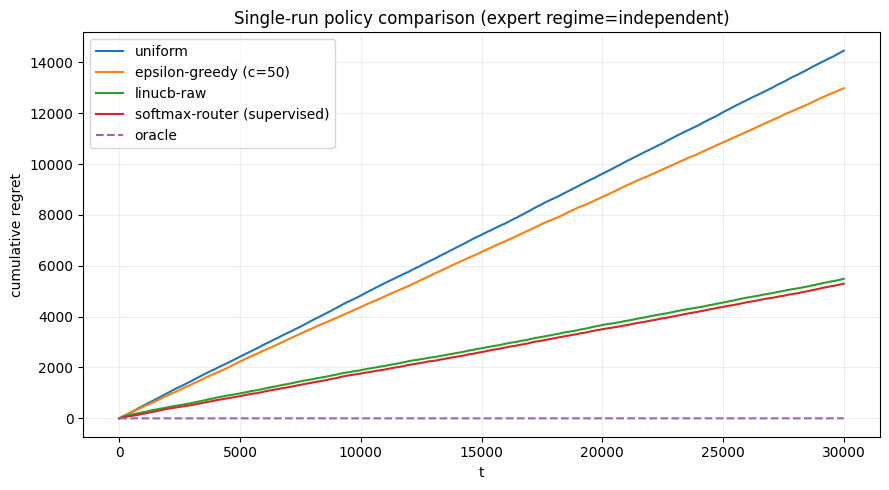

final cumulative regret:
  uniform        : 14460.4819
  epsilon-greedy : 12985.7356
  linucb-raw     : 5490.7980
  softmax-router : 5297.4720
  oracle         : 0.0000


In [3]:
# Align with 02_single_run.ipynb-style knobs (grid uses min-max reward rescale, not the notebook-only formula in 02).
K = 5
d = 10
contamination = 0.05
cluster_sep = 2.0

seed_train_data = 101
seed_train_experts = 201
seed_bandit_stream = 301
seed_policy = 401

EXPERT_REGIME = "independent"  # or "joint"

settings = FixedSettings(
    K=K,
    d=d,
    T=30_000,
    softmax_epochs=300,
    joint_moe_max_epochs=80,
    joint_moe_early_stopping_patience=15,
)

out = project_root / "outputs" / "phase2_single_run"
rows, artifacts = run_main_grid(
    output_dir=out,
    settings=settings,
    contaminations=[contamination],
    cluster_seps=[cluster_sep],
    seed_bundles=[(seed_train_data, seed_train_experts, seed_bandit_stream, seed_policy)],
    expert_training_regimes=(EXPERT_REGIME,),
    write_approx_error_jsonl=False,
    log_level=logging.INFO,
)

seed_idx = 0
cfg_name = f"contam_{contamination:.2f}_sep_{cluster_sep:.1f}_seed_{seed_idx}"
run_key = f"{cfg_name}__{EXPERT_REGIME}"
run_store = artifacts["runs"][run_key]
pol = run_store["policies"]

# Plot in the same cell so `pol` exists only after the full grid run finishes (no separate cell ordering issues).
uniform_curve = np.asarray(pol["uniform"]["cumulative_regret_curve"], dtype=float)
eps_curve = np.asarray(pol["epsilon_greedy"]["cumulative_regret_curve"], dtype=float)
linucb_curve = np.asarray(pol["linucb_raw"]["cumulative_regret_curve"], dtype=float)
softmax_curve = np.asarray(pol["softmax_router"]["cumulative_regret_curve"], dtype=float)
oracle_curve = np.asarray(pol["oracle"]["cumulative_regret_curve"], dtype=float)

plt.figure(figsize=(9, 5))
plt.plot(uniform_curve, label="uniform")
plt.plot(eps_curve, label="epsilon-greedy (c=50)")
plt.plot(linucb_curve, label="linucb-raw")
plt.plot(softmax_curve, label="softmax-router (supervised)")
plt.plot(oracle_curve, label="oracle", linestyle="--")
plt.xlabel("t")
plt.ylabel("cumulative regret")
plt.title(f"Single-run policy comparison (expert regime={EXPERT_REGIME})")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print("final cumulative regret:")
print(f"  uniform        : {float(uniform_curve[-1]):.4f}")
print(f"  epsilon-greedy : {float(eps_curve[-1]):.4f}")
print(f"  linucb-raw     : {float(linucb_curve[-1]):.4f}")
print(f"  softmax-router : {float(softmax_curve[-1]):.4f}")
print(f"  oracle         : {float(oracle_curve[-1]):.4f}")

Regret curves are drawn in the **previous** code cell after `run_main_grid` finishes (run + plot together so `pol` is always defined).

Starting grid: output_dir=/Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run
Grid size: 1 cells (contaminations=1 × seps=1 × seeds=1), T=30000, n_train=20000
[1/1] contam_0.05_sep_1.5_seed_0 | contam=0.05 sep=1.5 | seeds train_data=101 train_experts=201 bandit=301 policy=401
Trained experts (joint) in 9.430s
Built R_raw (joint) in 0.012s shape=(30000, 10)


[joint MoE] training complete: early stop after 20 epochs; best val acc=0.4785 (epoch 5), checkpoint train acc=0.4661, checkpoint val acc=0.4785, gate means=[0.0834, 0.1026, 0.1003, 0.1044, 0.1133, 0.0702, 0.0889, 0.1367, 0.0842, 0.116]


Trained softmax router (joint) in 30.277s (epochs=300, hidden=64, batch=64, lr=0.001)
Softmax in-sample metrics (joint): acc=0.4499 loss=1.563630
Policy uniform        (joint) done in 0.020s | final_cum_regret=10861.6397 avg_regret=0.362055 best_arm_acc=0.0993 mean_r=0.4564
Policy epsilon_greedy (joint) done in 0.032s | final_cum_regret=8439.0926 avg_regret=0.281303 best_arm_acc=0.0952 mean_r=0.5372
Policy linucb_raw     (joint) done in 0.974s | final_cum_regret=6382.5003 avg_regret=0.212750 best_arm_acc=0.2391 mean_r=0.6057
Policy softmax_router (joint) done in 0.247s | final_cum_regret=6258.9914 avg_regret=0.208633 best_arm_acc=0.4499 mean_r=0.6099
Policy oracle         (joint) done in 0.007s | final_cum_regret=0.0000 avg_regret=0.000000 best_arm_acc=1.0000 mean_r=0.8185
Finished cell contam_0.05_sep_1.5_seed_0 in 41.032s
Writing tables and artifacts...
Building plots...
Done.


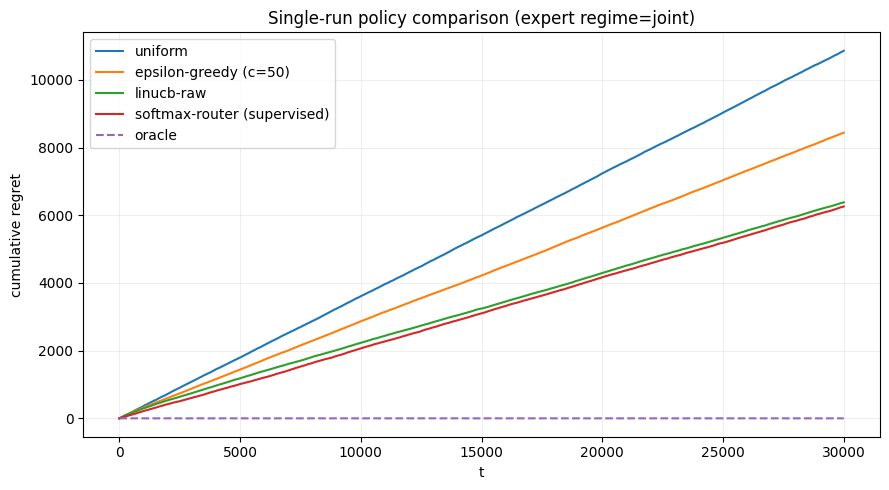

final cumulative regret:
  uniform        : 10861.6397
  epsilon-greedy : 8439.0926
  linucb-raw     : 6382.5003
  softmax-router : 6258.9914
  oracle         : 0.0000


In [4]:
# Align with 02_single_run.ipynb-style knobs (grid uses min-max reward rescale, not the notebook-only formula in 02).
K = 10
d = 10
contamination = 0.05
cluster_sep = 1.5

seed_train_data = 101
seed_train_experts = 201
seed_bandit_stream = 301
seed_policy = 401

EXPERT_REGIME = "joint"  # or "joint"

settings = FixedSettings(
    K=K,
    d=d,
    T=30_000,
    softmax_epochs=300,
    joint_moe_max_epochs=80,
    joint_moe_early_stopping_patience=15,
)

out = project_root / "outputs" / "phase2_single_run"
rows, artifacts = run_main_grid(
    output_dir=out,
    settings=settings,
    contaminations=[contamination],
    cluster_seps=[cluster_sep],
    seed_bundles=[(seed_train_data, seed_train_experts, seed_bandit_stream, seed_policy)],
    expert_training_regimes=(EXPERT_REGIME,),
    write_approx_error_jsonl=False,
    log_level=logging.INFO,
)

seed_idx = 0
cfg_name = f"contam_{contamination:.2f}_sep_{cluster_sep:.1f}_seed_{seed_idx}"
run_key = f"{cfg_name}__{EXPERT_REGIME}"
run_store = artifacts["runs"][run_key]
pol = run_store["policies"]

# Plot in the same cell so `pol` exists only after the full grid run finishes (no separate cell ordering issues).
uniform_curve = np.asarray(pol["uniform"]["cumulative_regret_curve"], dtype=float)
eps_curve = np.asarray(pol["epsilon_greedy"]["cumulative_regret_curve"], dtype=float)
linucb_curve = np.asarray(pol["linucb_raw"]["cumulative_regret_curve"], dtype=float)
softmax_curve = np.asarray(pol["softmax_router"]["cumulative_regret_curve"], dtype=float)
oracle_curve = np.asarray(pol["oracle"]["cumulative_regret_curve"], dtype=float)

plt.figure(figsize=(9, 5))
plt.plot(uniform_curve, label="uniform")
plt.plot(eps_curve, label="epsilon-greedy (c=50)")
plt.plot(linucb_curve, label="linucb-raw")
plt.plot(softmax_curve, label="softmax-router (supervised)")
plt.plot(oracle_curve, label="oracle", linestyle="--")
plt.xlabel("t")
plt.ylabel("cumulative regret")
plt.title(f"Single-run policy comparison (expert regime={EXPERT_REGIME})")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print("final cumulative regret:")
print(f"  uniform        : {float(uniform_curve[-1]):.4f}")
print(f"  epsilon-greedy : {float(eps_curve[-1]):.4f}")
print(f"  linucb-raw     : {float(linucb_curve[-1]):.4f}")
print(f"  softmax-router : {float(softmax_curve[-1]):.4f}")
print(f"  oracle         : {float(oracle_curve[-1]):.4f}")

### Optional: LinUCB + softmax only, independent vs joint

Run after you are happy with the single-regime plot. Set `RUN_COMPARE = True` and execute the next cell.

Starting grid: output_dir=/Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run_compare
Grid size: 1 cells (contaminations=1 × seps=1 × seeds=1), T=10000, n_train=8000
[1/1] contam_0.05_sep_1.5_seed_0 | contam=0.05 sep=1.5 | seeds train_data=101 train_experts=201 bandit=301 policy=401
Trained experts (independent) in 1.058s
Built R_raw (independent) in 0.003s shape=(10000, 4)
Trained softmax router (independent) in 9.767s (epochs=300, hidden=64, batch=64, lr=0.001)
Softmax in-sample metrics (independent): acc=0.7314 loss=0.688393
Policy uniform        (independent) done in 0.006s | final_cum_regret=3077.0394 avg_regret=0.307704 best_arm_acc=0.2518 mean_r=0.6864
Policy epsilon_greedy (independent) done in 0.016s | final_cum_regret=3178.1997 avg_regret=0.317820 best_arm_acc=0.2498 mean_r=0.6763
Policy linucb_raw     (independent) done in 0.276s | final_cum_regret=2747.4541 avg_regret=0.274745 best_arm_acc=0.3842 mean_r=0.719

[joint MoE] training complete: early stop after 18 epochs; best val acc=0.7050 (epoch 3), checkpoint train acc=0.7028, checkpoint val acc=0.7050, gate means=[0.1905, 0.2036, 0.2517, 0.3542]


Trained softmax router (joint) in 9.882s (epochs=300, hidden=64, batch=64, lr=0.001)
Softmax in-sample metrics (joint): acc=0.6849 loss=0.784358
Policy uniform        (joint) done in 0.006s | final_cum_regret=848.8396 avg_regret=0.084884 best_arm_acc=0.2510 mean_r=0.8611
Policy epsilon_greedy (joint) done in 0.022s | final_cum_regret=680.2727 avg_regret=0.068027 best_arm_acc=0.1392 mean_r=0.8780
Policy linucb_raw     (joint) done in 0.278s | final_cum_regret=701.2701 avg_regret=0.070127 best_arm_acc=0.3001 mean_r=0.8759
Policy softmax_router (joint) done in 0.082s | final_cum_regret=738.3991 avg_regret=0.073840 best_arm_acc=0.6849 mean_r=0.8722
Policy oracle         (joint) done in 0.002s | final_cum_regret=0.0000 avg_regret=0.000000 best_arm_acc=1.0000 mean_r=0.9460
Finished cell contam_0.05_sep_1.5_seed_0 in 23.240s
Writing tables and artifacts...
Wrote linear approx errors: /Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_sin

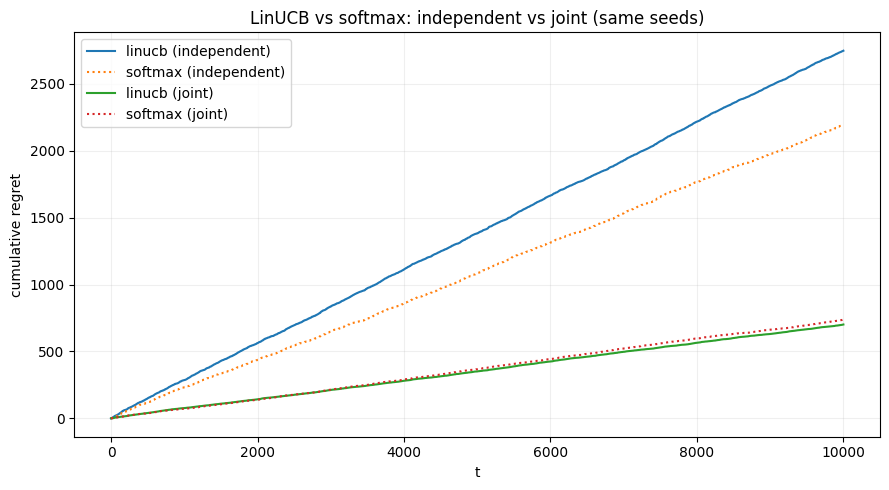

In [5]:
RUN_COMPARE = True

if RUN_COMPARE:
    rows_both, art_both = run_main_grid(
        output_dir=project_root / "outputs" / "phase2_single_run_compare",
        settings=settings,
        contaminations=[contamination],
        cluster_seps=[cluster_sep],
        seed_bundles=[(seed_train_data, seed_train_experts, seed_bandit_stream, seed_policy)],
        expert_training_regimes=("independent", "joint"),
        write_approx_error_jsonl=True,
        log_level=logging.INFO,
    )
    plt.figure(figsize=(9, 5))
    for regime in ("independent", "joint"):
        rk = f"{cfg_name}__{regime}"
        p = art_both["runs"][rk]["policies"]
        plt.plot(
            p["linucb_raw"]["cumulative_regret_curve"],
            label=f"linucb ({regime})",
        )
        plt.plot(
            p["softmax_router"]["cumulative_regret_curve"],
            label=f"softmax ({regime})",
            linestyle=":",
        )
    plt.xlabel("t")
    plt.ylabel("cumulative regret")
    plt.title("LinUCB vs softmax: independent vs joint (same seeds)")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Set RUN_COMPARE = True to train both regimes and overlay LinUCB/softmax.")

Starting grid: output_dir=/Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run_d64_t100k
Grid size: 1 cells (contaminations=1 × seps=1 × seeds=1), T=100000, n_train=51200
[1/1] contam_0.05_sep_1.5_seed_0 | contam=0.05 sep=1.5 | seeds train_data=101 train_experts=201 bandit=301 policy=401
Trained experts (joint) in 11.239s
Built R_raw (joint) in 0.016s shape=(100000, 4)


[joint MoE] training complete: early stop after 16 epochs; best val acc=0.6830 (epoch 1), checkpoint train acc=0.6989, checkpoint val acc=0.6830, gate means=[0.2469, 0.2554, 0.2828, 0.2149]


Trained softmax router (joint) in 119.707s (epochs=300, hidden=64, batch=64, lr=0.001)
Softmax in-sample metrics (joint): acc=0.6964 loss=0.745079
Policy uniform        (joint) done in 0.074s | final_cum_regret=18697.0490 avg_regret=0.186970 best_arm_acc=0.2477 mean_r=0.6839
Policy epsilon_greedy (joint) done in 0.118s | final_cum_regret=16716.2244 avg_regret=0.167162 best_arm_acc=0.1485 mean_r=0.7037
Policy linucb_raw     (joint) done in 15.641s | final_cum_regret=7852.5266 avg_regret=0.078525 best_arm_acc=0.5180 mean_r=0.7924
Policy softmax_router (joint) done in 1.068s | final_cum_regret=6785.3911 avg_regret=0.067854 best_arm_acc=0.6964 mean_r=0.8030
Policy oracle         (joint) done in 0.025s | final_cum_regret=0.0000 avg_regret=0.000000 best_arm_acc=1.0000 mean_r=0.8709
Finished cell contam_0.05_sep_1.5_seed_0 in 148.079s
Writing tables and artifacts...
Wrote linear approx errors: /Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/

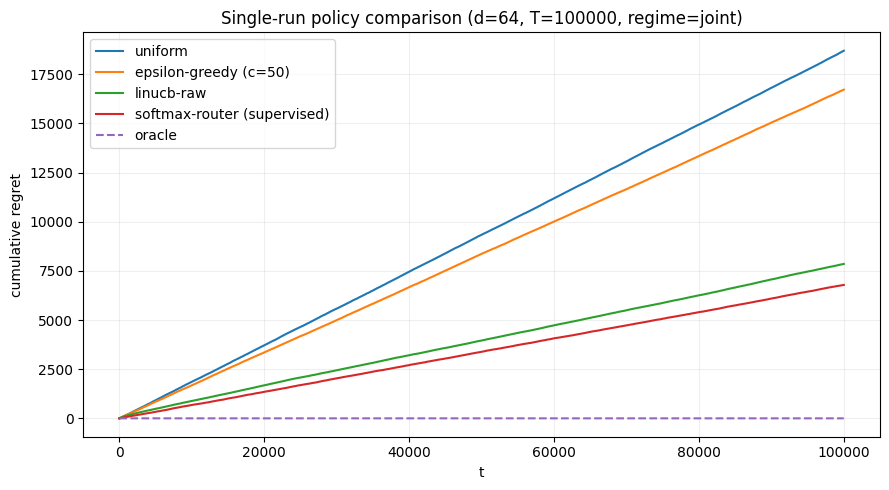

final cumulative regret:
  uniform        : 18697.0490
  epsilon-greedy : 16716.2244
  linucb-raw     : 7852.5266
  softmax-router : 6785.3911
  oracle         : 0.0000
saved to: /Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run_d64_t100k


In [6]:
# Single high-d run: d=64, T=100k
K = 4
d = 64
T = 100_000
cluster_sep = 1.5
contamination = 0.05  # ignored by joint training; kept only for run_main_grid API compatibility

seed_train_data = 101
seed_train_experts = 201
seed_bandit_stream = 301
seed_policy = 401

EXPERT_REGIME = "joint"

# Scale training data with dimensionality (baseline: d=10 -> 2000 per cluster).
n_train_per_cluster = int(2000 * d / 10)

settings = FixedSettings(
    K=K,
    d=d,
    T=T,
    n_train_per_cluster=n_train_per_cluster,
    softmax_epochs=300,
    joint_moe_max_epochs=80,
    joint_moe_early_stopping_patience=15,
)

out = project_root / "outputs" / "phase2_single_run_d64_t100k"
rows, artifacts = run_main_grid(
    output_dir=out,
    settings=settings,
    contaminations=[contamination],
    cluster_seps=[cluster_sep],
    seed_bundles=[(seed_train_data, seed_train_experts, seed_bandit_stream, seed_policy)],
    expert_training_regimes=(EXPERT_REGIME,),
    write_approx_error_jsonl=True,
    log_level=logging.INFO,
)

seed_idx = 0
cfg_name = f"contam_{contamination:.2f}_sep_{cluster_sep:.1f}_seed_{seed_idx}"
run_key = f"{cfg_name}__{EXPERT_REGIME}"
run_store = artifacts["runs"][run_key]
pol = run_store["policies"]

uniform_curve = np.asarray(pol["uniform"]["cumulative_regret_curve"], dtype=float)
eps_curve = np.asarray(pol["epsilon_greedy"]["cumulative_regret_curve"], dtype=float)
linucb_curve = np.asarray(pol["linucb_raw"]["cumulative_regret_curve"], dtype=float)
softmax_curve = np.asarray(pol["softmax_router"]["cumulative_regret_curve"], dtype=float)
oracle_curve = np.asarray(pol["oracle"]["cumulative_regret_curve"], dtype=float)

plt.figure(figsize=(9, 5))
plt.plot(uniform_curve, label="uniform")
plt.plot(eps_curve, label="epsilon-greedy (c=50)")
plt.plot(linucb_curve, label="linucb-raw")
plt.plot(softmax_curve, label="softmax-router (supervised)")
plt.plot(oracle_curve, label="oracle", linestyle="--")
plt.xlabel("t")
plt.ylabel("cumulative regret")
plt.title(f"Single-run policy comparison (d={d}, T={T}, regime={EXPERT_REGIME})")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print("final cumulative regret:")
print(f"  uniform        : {float(uniform_curve[-1]):.4f}")
print(f"  epsilon-greedy : {float(eps_curve[-1]):.4f}")
print(f"  linucb-raw     : {float(linucb_curve[-1]):.4f}")
print(f"  softmax-router : {float(softmax_curve[-1]):.4f}")
print(f"  oracle         : {float(oracle_curve[-1]):.4f}")
print(f"saved to: {out}")

Starting grid: output_dir=/Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run_d64_t100k
Grid size: 1 cells (contaminations=1 × seps=1 × seeds=1), T=100000, n_train=12800
[1/1] contam_0.05_sep_1.5_seed_0 | contam=0.05 sep=1.5 | seeds train_data=101 train_experts=201 bandit=301 policy=401
Trained experts (joint) in 3.254s
Built R_raw (joint) in 0.019s shape=(100000, 4)


[joint MoE] training complete: early stop after 20 epochs; best val acc=0.6805 (epoch 5), checkpoint train acc=0.6903, checkpoint val acc=0.6805, gate means=[0.2661, 0.2547, 0.1989, 0.2804]


Trained softmax router (joint) in 103.624s (epochs=300, hidden=64, batch=64, lr=0.001)
Softmax in-sample metrics (joint): acc=0.6896 loss=0.773424
Policy uniform        (joint) done in 0.065s | final_cum_regret=13608.8890 avg_regret=0.136089 best_arm_acc=0.2501 mean_r=0.7466
Policy epsilon_greedy (joint) done in 0.106s | final_cum_regret=9260.8076 avg_regret=0.092608 best_arm_acc=0.2835 mean_r=0.7901
Policy linucb_raw     (joint) done in 3.033s | final_cum_regret=8448.1206 avg_regret=0.084481 best_arm_acc=0.4358 mean_r=0.7982
Policy softmax_router (joint) done in 0.850s | final_cum_regret=6497.6544 avg_regret=0.064977 best_arm_acc=0.6896 mean_r=0.8177
Policy oracle         (joint) done in 0.029s | final_cum_regret=0.0000 avg_regret=0.000000 best_arm_acc=1.0000 mean_r=0.8827
Finished cell contam_0.05_sep_1.5_seed_0 in 111.100s
Writing tables and artifacts...
Wrote linear approx errors: /Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/ph

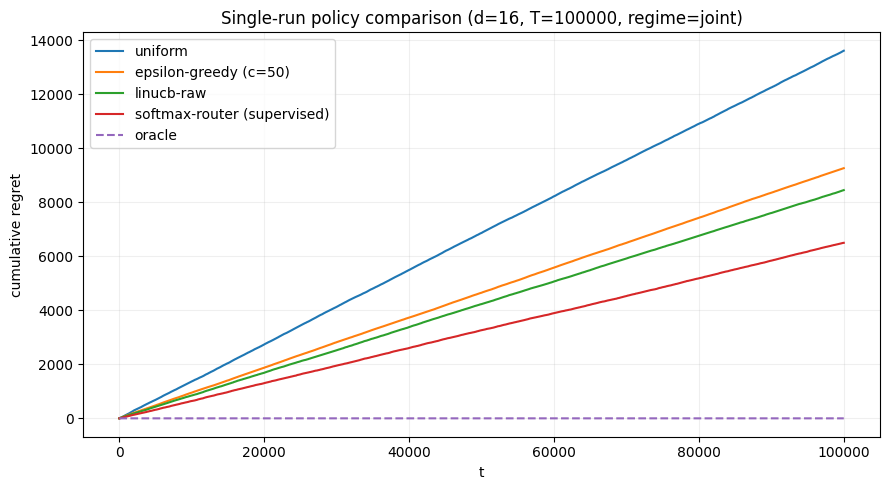

final cumulative regret:
  uniform        : 13608.8890
  epsilon-greedy : 9260.8076
  linucb-raw     : 8448.1206
  softmax-router : 6497.6544
  oracle         : 0.0000
saved to: /Users/arnaldpaguio/Documents/BU Academics/Spring 2026/DS592/Project/moe_contextual_bandits/outputs/phase2_single_run_d64_t100k


In [7]:
# Single high-d run: d=64, T=100k
K = 4
d = 16
T = 100_000
cluster_sep = 1.5
contamination = 0.05  # ignored by joint training; kept only for run_main_grid API compatibility

seed_train_data = 101
seed_train_experts = 201
seed_bandit_stream = 301
seed_policy = 401

EXPERT_REGIME = "joint"

# Scale training data with dimensionality (baseline: d=10 -> 2000 per cluster).
n_train_per_cluster = int(2000 * d / 10)

settings = FixedSettings(
    K=K,
    d=d,
    T=T,
    n_train_per_cluster=n_train_per_cluster,
    softmax_epochs=300,
    joint_moe_max_epochs=80,
    joint_moe_early_stopping_patience=15,
)

out = project_root / "outputs" / "phase2_single_run_d64_t100k"
rows, artifacts = run_main_grid(
    output_dir=out,
    settings=settings,
    contaminations=[contamination],
    cluster_seps=[cluster_sep],
    seed_bundles=[(seed_train_data, seed_train_experts, seed_bandit_stream, seed_policy)],
    expert_training_regimes=(EXPERT_REGIME,),
    write_approx_error_jsonl=True,
    log_level=logging.INFO,
)

seed_idx = 0
cfg_name = f"contam_{contamination:.2f}_sep_{cluster_sep:.1f}_seed_{seed_idx}"
run_key = f"{cfg_name}__{EXPERT_REGIME}"
run_store = artifacts["runs"][run_key]
pol = run_store["policies"]

uniform_curve = np.asarray(pol["uniform"]["cumulative_regret_curve"], dtype=float)
eps_curve = np.asarray(pol["epsilon_greedy"]["cumulative_regret_curve"], dtype=float)
linucb_curve = np.asarray(pol["linucb_raw"]["cumulative_regret_curve"], dtype=float)
softmax_curve = np.asarray(pol["softmax_router"]["cumulative_regret_curve"], dtype=float)
oracle_curve = np.asarray(pol["oracle"]["cumulative_regret_curve"], dtype=float)

plt.figure(figsize=(9, 5))
plt.plot(uniform_curve, label="uniform")
plt.plot(eps_curve, label="epsilon-greedy (c=50)")
plt.plot(linucb_curve, label="linucb-raw")
plt.plot(softmax_curve, label="softmax-router (supervised)")
plt.plot(oracle_curve, label="oracle", linestyle="--")
plt.xlabel("t")
plt.ylabel("cumulative regret")
plt.title(f"Single-run policy comparison (d={d}, T={T}, regime={EXPERT_REGIME})")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print("final cumulative regret:")
print(f"  uniform        : {float(uniform_curve[-1]):.4f}")
print(f"  epsilon-greedy : {float(eps_curve[-1]):.4f}")
print(f"  linucb-raw     : {float(linucb_curve[-1]):.4f}")
print(f"  softmax-router : {float(softmax_curve[-1]):.4f}")
print(f"  oracle         : {float(oracle_curve[-1]):.4f}")
print(f"saved to: {out}")